<a href="https://colab.research.google.com/github/Rithvikns/python/blob/main/Framework/Pytorch/Computational_graph/Static_computation_graph.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [31]:
!pip install torchviz


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 1.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 46.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 54.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 56.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 1.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 13.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 77.9 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstalling nvidia-nvjitlink-cu12-12.5.82:
      Successfully uninstalled nvidia-nvjitlin

In [32]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchviz import make_dot


In [33]:
# Define a simple neural network
class DynamicNet(nn.Module):
    def __init__(self):
        super(DynamicNet, self).__init__()
        self.fc1 = nn.Linear(2, 4)  # Input: 2 features, Output: 4 neurons
        self.fc2 = nn.Linear(4, 1)  # Output: 1 neuron

    def forward(self, x):
        x = torch.relu(self.fc1(x))  # First layer with ReLU activation

        # Dynamic behavior: randomly decide whether to use extra computation
        if torch.rand(1).item() > 0.5:
            print("Applying extra layer dynamically")
            x = torch.relu(self.fc2(x))

        return x

In [34]:
# Create model instance
model = DynamicNet()

# Example input tensor
x_input = torch.tensor([[0.5, -1.2]], dtype=torch.float32)

# Forward pass (executing dynamic graph)
output = model(x_input)
print("Output:", output)

# Backward pass to show dynamic graph in action
target = torch.tensor([[1.0]])  # Target value
loss_fn = nn.MSELoss()  # Mean squared error loss
optimizer = optim.SGD(model.parameters(), lr=0.01)


Applying extra layer dynamically
Output: tensor([[0.]], grad_fn=<ReluBackward0>)


In [35]:
loss = loss_fn(output, target)
print("Loss:", loss.item())

# Compute gradients dynamically
loss.backward()
optimizer.step()  # Update weights

print("Backward pass done with dynamic computation graph!")

Loss: 1.0
Backward pass done with dynamic computation graph!


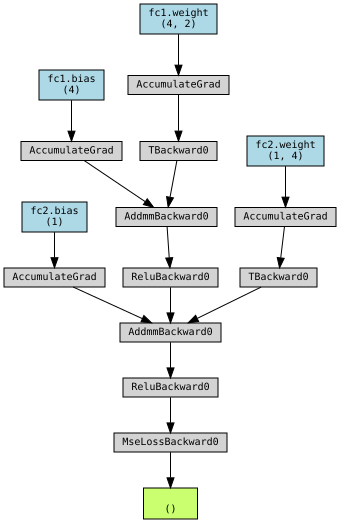

In [36]:
# Generate computation graph visualization
dot = make_dot(loss, params=dict(model.named_parameters()))
dot.render("dynamic_graph", format="png")  # Save as PNG
dot  # Display in notebook